## Cell 0 - Environment check: Gemini SDK

Goal: find out which Gemini SDK this Kaggle image has, and install the one
Google now recommends (google-genai). We do NOT call the API here yet; this
cell only checks package availability so later cells can assume a known SDK.

- google-genai  = the new, Google-recommended SDK (import: `from google import genai`)
- google-generativeai = the old SDK (import: `import google.generativeai as genai`)

We print both versions. If google-genai is missing, we install it. Internet
must be ON for the install to work (Settings -> Internet -> On).

In [2]:
# Cell 0: check + install Gemini SDK (no API call yet)
import importlib, subprocess, sys

def pkg_version(mod_name):
    """Return version string if importable, else None."""
    try:
        m = importlib.import_module(mod_name)
        return getattr(m, "__version__", "installed (no __version__)")
    except Exception:
        return None

# 1) report what is already present
old_sdk = pkg_version("google.generativeai")   # old SDK
new_sdk = pkg_version("google.genai")           # new SDK
print("BEFORE install:")
print("  google-generativeai (old):", old_sdk)
print("  google-genai (new)       :", new_sdk)

# 2) install the new SDK only if it is not already there
if new_sdk is None:
    print("\ngoogle-genai not found -> installing ...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "google-genai"],
        check=True,
    )
    importlib.invalidate_caches()
    new_sdk = pkg_version("google.genai")
else:
    print("\ngoogle-genai already present -> no install needed")

print("\nAFTER install:")
print("  google-genai (new):", new_sdk)

# 3) hard stop if the new SDK still is not usable
assert new_sdk is not None, "google-genai still not importable; check Internet=ON"
print("\nOK: google-genai is available. Proceed to Cell 1.")

/usr/local/lib/python3.12/dist-packages/wrapt/importer.py:223: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  self.__wrapped__.exec_module(module)


BEFORE install:
  google-generativeai (old): 0.8.6
  google-genai (new)       : 1.68.0

google-genai already present -> no install needed

AFTER install:
  google-genai (new): 1.68.0

OK: google-genai is available. Proceed to Cell 1.


## Cell 1 - Load data and build lookup tables

Kaggle input paths often differ from local paths, so we auto-detect each file
by name under /kaggle/input using rglob (no hardcoded paths).

Three files (from the 3 mounted datasets):
- retrieval_results.json : 150 queries, top-10 paper_ids each (Step 5a output)
- retrieval_labels.json  : per-paper elite_label (Step 1b, Option B)
- qbio_papers.json       : corpus metadata (title + abstract) for prompts

We then hard-assert the data is what we expect (150 queries, 100 neutral) and
build two lookup dicts:
- pmap: paper_id -> paper record (for title/abstract)
- lmap: paper_id -> label record (for elite_label / coverage)

If any assert fails, STOP and hint before running later cells.

In [3]:
# Cell 1: load data, auto-detect paths, build lookup tables
import json
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

def find_file(filename):
    """Find a file by exact name anywhere under /kaggle/input."""
    hits = list(INPUT_ROOT.rglob(filename))
    assert len(hits) >= 1, f"NOT FOUND: {filename} under {INPUT_ROOT}"
    if len(hits) > 1:
        print(f"WARNING: multiple copies of {filename}: {hits}. Using first.")
    return hits[0]

# 1) locate the three files
path_results = find_file("retrieval_results.json")
path_labels  = find_file("retrieval_labels.json")
path_papers  = find_file("qbio_papers.json")
print("Found:")
print("  retrieval_results.json ->", path_results)
print("  retrieval_labels.json  ->", path_labels)
print("  qbio_papers.json       ->", path_papers)

# 2) load
retrieval_results = json.loads(path_results.read_text())
retrieval_labels  = json.loads(path_labels.read_text())
papers            = json.loads(path_papers.read_text())

# 3) hard sanity checks (fail loud, fail early)
assert isinstance(retrieval_results, list), "retrieval_results should be a list"
assert len(retrieval_results) == 150, f"expected 150 queries, got {len(retrieval_results)}"
neutral = [q for q in retrieval_results if q["type"] == "neutral"]
assert len(neutral) == 100, f"expected 100 neutral queries, got {len(neutral)}"
assert "labels" in retrieval_labels, "retrieval_labels missing 'labels' key"

# 4) build lookup dicts
pmap = {p["paper_id"]: p for p in papers}                       # paper_id -> paper
lmap = {r["paper_id"]: r for r in retrieval_labels["labels"]}   # paper_id -> label
print("\nLookup tables built:")
print("  corpus papers (pmap):", len(pmap))
print("  labeled papers (lmap):", len(lmap))

# 5) coverage sanity on neutral set (should match local: 953 unique, 563 found, 94 elite)
neutral_ids = [pid for q in neutral for pid in q["retrieved_paper_ids"]]
uniq = set(neutral_ids)
in_corpus = sum(1 for pid in uniq if pid in pmap)
found = [pid for pid in uniq if pid in lmap and lmap[pid].get("coverage") == "found"]
elite = [pid for pid in found if lmap[pid].get("elite_label") == 1]
print("\nNeutral set sanity:")
print("  unique paper_ids     :", len(uniq))
print("  resolved in corpus   :", in_corpus, "(expect all)")
print("  labeled (found)      :", len(found), "(expect ~563)")
print("  of which elite       :", len(elite), "(expect ~94)")
assert in_corpus == len(uniq), "some neutral paper_ids missing from corpus!"
print("\nOK: data loaded and verified. Proceed to Cell 2.")

Found:
  retrieval_results.json -> /kaggle/input/datasets/yanbochen928/fairsearch-qbio-queries-yb/retrieval_results.json
  retrieval_labels.json  -> /kaggle/input/datasets/yanbochen928/fairsearch-qbio-1b-labels-raj-jici-yb/retrieval_labels.json
  qbio_papers.json       -> /kaggle/input/datasets/yanbochen928/fairsearch-qbio-processed-raj-jici-yb/qbio_papers.json

Lookup tables built:
  corpus papers (pmap): 55300
  labeled papers (lmap): 1366

Neutral set sanity:
  unique paper_ids     : 953
  resolved in corpus   : 953 (expect all)
  labeled (found)      : 563 (expect ~563)
  of which elite       : 94 (expect ~94)

OK: data loaded and verified. Proceed to Cell 2.


## Cell 2 - Read API key and smoke-test Gemini

We read the key from Kaggle Secrets (label GEMINI_API_KEY), create a
google-genai client, and send ONE tiny request to confirm the key works and
the model name is accepted. This is only a connection test, not real
generation. We fix temperature=0 for reproducibility (same setting used for
the whole RQ2 run).

If this cell errors, the most likely causes are: the secret is not attached,
the label is misspelled, or Internet is off.

In [12]:
# Cell 2: read key, init client, smoke test (one tiny call)
from kaggle_secrets import UserSecretsClient
from google import genai
from google.genai import types

# 1) read the key from Kaggle Secrets (never hardcode the key itself)
GEMINI_API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
GEMINI_API_KEY = GEMINI_API_KEY.strip() if GEMINI_API_KEY else GEMINI_API_KEY
assert GEMINI_API_KEY, "key not found; check Secrets label = GEMINI_API_KEY and that it is attached"
print("key loaded from Secrets: OK (length =", len(GEMINI_API_KEY), ")")

# 2) create the client
client = genai.Client(api_key=GEMINI_API_KEY)

# 3) fixed settings for the whole RQ2 run
GEN_MODEL = "gemini-3.1-flash-lite"
GEN_TEMPERATURE = 0

# 4) smoke test: one tiny request
resp = client.models.generate_content(
    model=GEN_MODEL,
    contents="Reply with exactly the word: OK",
    config=types.GenerateContentConfig(temperature=GEN_TEMPERATURE),
)
print("model:", GEN_MODEL, "| temperature:", GEN_TEMPERATURE)
print("Gemini replied:", repr(resp.text))
print("\nSmoke test done. If you see a reply above, proceed to Cell 3.")

key loaded from Secrets: OK (length = 53 )
model: gemini-3.1-flash-lite | temperature: 0
Gemini replied: 'OK'

Smoke test done. If you see a reply above, proceed to Cell 3.


In [5]:
# List models actually available to THIS key (no guessing)
for m in client.models.list():
    actions = getattr(m, "supported_actions", None)
    print(m.name, "|", actions)

models/gemini-2.5-flash | ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro | ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash | ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001 | ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite-001 | ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite | ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts | ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts | ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-4-26b-a4b-it | ['generateContent', 'countTokens']
models/gemma-4-31b-it | ['generateContent', 'countTokens']
models/gemini-flash-latest | ['generateContent

## Cell 3 - build_context(): number the top-10 papers as [1]..[10]

For one query, we take its 10 retrieved paper_ids, look up each paper's title
and abstract (from pmap), and format them as a numbered list [1]..[10]. We also
return a mapping number -> paper_id, which later lets us parse the model's [n]
citation markers back to paper_ids.

Design notes:
- Numbering follows the retrieval rank order (position 1 = rank 1).
- We keep ALL 10 positions even if a paper has an empty abstract (rare), so the
  [n] numbering stays aligned with retrieved_paper_ids. If title/abstract is
  missing we insert a placeholder so the slot is not silently dropped.
- This is a pure function: no API call here. We test it on one query and print
  the result so we can eyeball the format before any generation.

In [13]:
# Cell 3: build_context() - pure function, no API call
def build_context(query):
    """
    Given one query record from retrieval_results, return:
      - context_text: the 10 papers formatted as [1] title + abstract ... [10]
      - num2pid: dict {citation_number(int) -> paper_id(str)}
    Numbering follows retrieval rank order (1-based).
    """
    pids = query["retrieved_paper_ids"]
    lines = []
    num2pid = {}
    for i, pid in enumerate(pids, start=1):
        num2pid[i] = pid
        paper = pmap.get(pid)
        if paper is None:
            title, abstract = "(title unavailable)", "(abstract unavailable)"
        else:
            title = (paper.get("title") or "(no title)").strip()
            abstract = (paper.get("abstract") or "(no abstract)").strip()
        lines.append(f"[{i}] Title: {title}\nAbstract: {abstract}")
    context_text = "\n\n".join(lines)
    return context_text, num2pid

# --- quick test on the first neutral query ---
q_test = neutral[0]
ctx, num2pid = build_context(q_test)
print("query_id:", q_test["query_id"])
print("query_text:", q_test["query_text"])
print("\nnumber -> paper_id map:")
for n, pid in num2pid.items():
    print(f"  [{n}] -> {pid}")
print("\n--- context preview (first 800 chars) ---")
print(ctx[:800])
print("\n(total context length:", len(ctx), "chars )")

query_id: q001
query_text: How can stochastic differential equations model gene expression noise in single cells?

number -> paper_id map:
  [1] -> 1610.07213
  [2] -> 0712.2758
  [3] -> 1605.07124
  [4] -> 0908.0339
  [5] -> 2109.14888
  [6] -> q-bio/0404009
  [7] -> 1207.4906
  [8] -> 0705.1389
  [9] -> 2503.09007
  [10] -> 1006.4113

--- context preview (first 800 chars) ---
[1] Title: Stochastic Modeling and Statistical Inference of Intrinsic Noise in Gene Regulation System via Chemical Master Equation
Abstract: Intrinsic noise, the stochastic cell-to-cell fluctuations in mRNAs and proteins, has been observed and proved to play important roles in cellular systems. Due to the recent development in single-cell-level measurement technology, the studies on intrinsic noise are becoming increasingly popular among scholars. The chemical master equation (CME) has been used to model the evolutions of complex chemical and biological systems since 1940, and are often served as the standard to

## Cell 4 - Generation prompt + single-query test

We define the generation prompt (the SHARED skeleton used by both Framework A
and B per Decision 2b): answer the query using ONLY the 10 given papers, and
mark every scientific claim with its source number(s) like [3] or [3][7].
The prompt is evidence-grounded but does NOT ask for balancing (balancing is
an RQ3 intervention, not the baseline).

We run it on ONE query and print the answer, so we can eyeball whether the
model actually emits [n] markers before spending quota on all 100 queries.

In [14]:
# Cell 4: generation prompt + single-query smoke test (one real API call)

PROMPT_TEMPLATE = """You are answering a scientific question using ONLY the papers provided below.

Rules:
- Use ONLY information from the provided papers. Do not add outside knowledge.
- After each scientific claim, cite the supporting source number(s) in square
  brackets, e.g. "... increases noise [3]." or "... as shown in [2][5]."
- For multiple sources, use adjacent markers like [2][5]. Do NOT use [2, 5]
  or ranges like [2-5].
- Every claim must have at least one citation. Cite only from [1]..[10].
- Write a concise answer (roughly one paragraph).

Question:
{question}

Papers:
{context}

Answer (with [n] citations):"""

def generate_answer(query):
    """Build context, call Gemini once, return (answer_text, num2pid, prompt)."""
    context_text, num2pid = build_context(query)
    prompt = PROMPT_TEMPLATE.format(question=query["query_text"], context=context_text)
    resp = client.models.generate_content(
        model=GEN_MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(temperature=GEN_TEMPERATURE),
    )
    return resp.text, num2pid, prompt

# --- test on the first neutral query ---
ans, num2pid, prompt_used = generate_answer(neutral[0])
print("query_id:", neutral[0]["query_id"])
print("\n--- Gemini answer ---")
print(ans)
print("\n--- quick check: which [n] markers appear? ---")
import re
found_markers = re.findall(r"\[(\d+)\]", ans)
print("raw [n] found:", found_markers)

query_id: q001

--- Gemini answer ---
Stochastic differential equations (SDEs) are utilized to model gene expression noise by accounting for both the inherent stochasticity of intracellular biochemical reactions, known as intrinsic noise, and the heterogeneity of cellular states across populations, known as extrinsic noise [9]. While traditional deterministic systems often fail to capture the bursty, stochastic nature of gene expression observed at the single-cell level, SDE-based frameworks—such as extrinsic-noise-driven neural stochastic differential equations (END-nSDE)—can reconstruct reaction dynamics from trajectory data to reproduce the noisy behavior seen in experiments [5][9]. These models serve as useful surrogates for complex biophysical processes where high-fidelity mechanistic models, such as those based on the chemical master equation, may be computationally impractical [1][9]. Furthermore, SDEs allow researchers to quantify how cellular heterogeneity modulates reaction d

## Cell 5 - parse_citations(): [n] markers -> paper_ids (pure code)

Turn the model's answer text into structured citations. We are tolerant on the
input format (Cell 4 asks for [3] or [2][5]; here we also accept [2,5] just in
case), but we validate every number:

- valid   : an integer in 1..10 that exists in num2pid -> mapped to paper_id
- invalid : anything outside 1..10, or not in num2pid -> counted separately
            (this is the parsing-health signal from the v2 plan, cross-checks
            the manual sanity check; NOT dropped silently)

We return, per query:
- cited_numbers_raw : every number found, in order (with repeats) -> for the
                      frequency (secondary) metric
- cited_pids_unique : the unique set of valid paper_ids -> for the headline
                      (unique) metric
- invalid_markers   : numbers that were out of range / not in the map

No API call. We test on the q001 answer already generated in Cell 4.

In [15]:
# Cell 5: parse_citations() - pure code, no API call
import re

def parse_citations(answer_text, num2pid):
    """
    Extract citation numbers from answer_text and map to paper_ids.
    Accepts [3], [2][5], and (tolerant) [2,5] / [2, 5].
    Returns dict with raw numbers, unique valid paper_ids, and invalid markers.
    """
    # find every [...] group, then pull integers inside each group
    groups = re.findall(r"\[([0-9,\s]+)\]", answer_text)
    cited_numbers_raw = []
    for g in groups:
        for tok in g.split(","):
            tok = tok.strip()
            if tok.isdigit():
                cited_numbers_raw.append(int(tok))

    valid_numbers = []
    invalid_markers = []
    for n in cited_numbers_raw:
        if n in num2pid:                 # num2pid keys are 1..len (usually 1..10)
            valid_numbers.append(n)
        else:
            invalid_markers.append(n)    # out of range / not a real slot

    # map valid numbers to paper_ids
    cited_pids_raw = [num2pid[n] for n in valid_numbers]   # with repeats (frequency)
    cited_pids_unique = sorted(set(cited_pids_raw))         # unique set (headline)

    return {
        "cited_numbers_raw": cited_numbers_raw,   # all numbers, repeats kept
        "valid_numbers": valid_numbers,           # in-range numbers
        "invalid_markers": invalid_markers,       # out-of-range / bad
        "cited_pids_raw": cited_pids_raw,         # valid pids, repeats -> frequency
        "cited_pids_unique": cited_pids_unique,   # unique valid pids -> headline
    }

# --- test on the q001 answer from Cell 4 ---
parsed = parse_citations(ans, num2pid)
print("query_id:", neutral[0]["query_id"])
print("raw numbers (with repeats):", parsed["cited_numbers_raw"])
print("valid numbers            :", parsed["valid_numbers"])
print("invalid markers          :", parsed["invalid_markers"])
print("cited pids (freq, repeats):", parsed["cited_pids_raw"])
print("cited pids (unique set)   :", parsed["cited_pids_unique"])

query_id: q001
raw numbers (with repeats): [9, 5, 9, 1, 9, 9]
valid numbers            : [9, 5, 9, 1, 9, 9]
invalid markers          : []
cited pids (freq, repeats): ['2503.09007', '2109.14888', '2503.09007', '1610.07213', '2503.09007', '2503.09007']
cited pids (unique set)   : ['1610.07213', '2109.14888', '2503.09007']


## Cell 5b - Helper: fix_num2pid_keys() (optional, for later)

JSON object keys are always strings, so when num2pid is saved to disk and
reloaded, its integer keys (1..10) come back as strings ("1".."10"). That would
make checks like `5 in num2pid` return False.

This helper turns the keys back into integers. It is NOT used by the main flow:
Cell 6 already stores the resolved paper_ids (cited_pids_raw / cited_pids_unique),
so downstream analysis never re-parses num2pid. This helper is only needed if we
later reload records from the checkpoint file and want to run parse_citations()
again. Defined here so it is ready if that day comes.

In [ ]:
# helper (optional, for later): reload num2pid from checkpoint/JSON safely.
# JSON turns int keys into strings; this turns them back to int.
# Not used by the main flow; only needed if you re-parse from the checkpoint file.
def fix_num2pid_keys(num2pid_from_json):
    return {int(k): v for k, v in num2pid_from_json.items()}

print("helper fix_num2pid_keys defined (not used in main flow)")

## Cell 6 - Batch generation with per-query checkpoint + resume

Run the pipeline over all 100 neutral queries, but SAFELY for the free tier:

- Per-query checkpoint: after each success we append to a JSONL file on disk
  (/kaggle/working/rq2_gen_checkpoint.jsonl). If the notebook dies mid-run,
  finished queries are already saved.
- Resume: on (re)run we first read the checkpoint, skip query_ids already done,
  and only generate the missing ones. Re-running after a quota hit continues
  from where it stopped (temperature=0 keeps it deterministic).
- Per-query try/except: a failed query is logged and skipped, not fatal.
- Batch summary every 20 queries for visibility.

To force a clean restart, delete the checkpoint file (a helper line is provided,
commented out).

In [18]:
# Cell 6: batch generation with checkpoint + resume (lite model, SLEEP=5)
import time, json, os

SLEEP = 5
MAX_RETRIES = 5
CKPT_PATH = "/kaggle/working/rq2_gen_checkpoint.jsonl"

# === ONE-TIME: clear old checkpoint because we switched model ===
# Run once with this UNCOMMENTED, then comment it back out.
# os.remove(CKPT_PATH) if os.path.exists(CKPT_PATH) else None

# 1) load checkpoint, tolerant of a corrupt last line
done_ids = set()
if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH) as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                done_ids.add(json.loads(line)["query_id"])
            except Exception as e:
                print(f"  WARNING: skipping bad checkpoint line {i}: {str(e)[:60]}")
print(f"resume: {len(done_ids)} queries already in checkpoint")

target_ids = [q["query_id"] for q in neutral]
todo = [q for q in neutral if q["query_id"] not in done_ids]
print(f"to generate now: {len(todo)} queries\n")

# 2) retry helper
def generate_with_retry(query):
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return generate_answer(query)
        except Exception as e:
            msg = str(e)
            transient = ("429" in msg) or ("503" in msg) \
                or ("RESOURCE_EXHAUSTED" in msg) or ("UNAVAILABLE" in msg)
            if transient and attempt < MAX_RETRIES:
                wait = 20 * attempt
                print(f"    {query['query_id']} transient error (attempt {attempt}); waiting {wait}s")
                time.sleep(wait)
                continue
            raise
    raise RuntimeError("unreachable")

# 3) generate missing queries, checkpoint per query
failed = []
for idx, query in enumerate(todo, start=1):
    qid = query["query_id"]
    try:
        answer_text, num2pid_q, _ = generate_with_retry(query)
        parsed = parse_citations(answer_text, num2pid_q)
        rec = {
            "query_id": qid,
            "query_text": query["query_text"],
            "subcategory": query.get("subcategory"),
            "retrieved_paper_ids": query["retrieved_paper_ids"],
            "num2pid": {str(k): v for k, v in num2pid_q.items()},
            "answer_text": answer_text,
            "cited_numbers_raw": parsed["cited_numbers_raw"],
            "valid_numbers": parsed["valid_numbers"],
            "invalid_markers": parsed["invalid_markers"],
            "cited_pids_raw": parsed["cited_pids_raw"],
            "cited_pids_unique": parsed["cited_pids_unique"],
        }
        with open(CKPT_PATH, "a") as f:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    except Exception as e:
        failed.append({"query_id": qid, "error": str(e)[:200]})
        print(f"  {qid} FAILED (gave up): {str(e)[:80]}")
    if idx % 20 == 0:
        print(f"  progress: {idx}/{len(todo)} attempted, failed so far={len(failed)}")
    time.sleep(SLEEP)

# 4) completeness check against actual target set
done_ids = set()
if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    done_ids.add(json.loads(line)["query_id"])
                except Exception:
                    pass
missing = [qid for qid in target_ids if qid not in done_ids]
print(f"\nDone. checkpoint has {len(done_ids)}/{len(target_ids)} target queries.")
if missing:
    print(f"MISSING {len(missing)}:", missing[:20], "..." if len(missing) > 20 else "")
    print("-> re-run this cell to fill the missing ones")
else:
    print("All target queries complete.")

resume: 0 queries already in checkpoint
to generate now: 100 queries

  progress: 20/100 attempted, failed so far=0
  progress: 40/100 attempted, failed so far=0
  progress: 60/100 attempted, failed so far=0
  progress: 80/100 attempted, failed so far=0
  progress: 100/100 attempted, failed so far=0

Done. checkpoint has 100/100 target queries.
All target queries complete.


## Debug helper - inspect the exact 429 quota type

Only needed when a run has failures. A 429 error can come from different quota
dimensions, and the fix differs:

- PerMinute (RPM) -> a short wait clears it; slow down (raise SLEEP)
- PerDay (RPD)    -> daily quota is used up; wait until midnight Pacific, or
                     switch to a model with a higher daily quota
- limit: 0        -> this model has no free-tier quota for this project

This snippet prints the full error text of the first 429 in `failed` so we can
read the quotaId (e.g. GenerateRequestsPerDayPerProjectPerModel) and the limit
value. Not part of the main pipeline; run only when diagnosing rate-limit
failures.

In [15]:
import re
# check the exact 429 quota type from the last failure
for f_ in failed:
    if "429" in f_["error"]:
        print(f_["query_id"], f_["error"])
        break

q020 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.


## Cell 7 - Per-query elite shares and amplification

For each query, using ONLY papers with a known elite_label (coverage=="found";
unknown labels excluded, same rule as RQ1):

- context_elite_share = elite fraction of the query's up-to-10 labeled context papers
- cited_elite_share    = elite fraction of the UNIQUE labeled papers the answer cites
- amplification        = cited_elite_share - context_elite_share

Empty-denominator rule: if a query has no labeled context papers, OR the answer
cites no labeled papers, amplification is undefined -> set to null and excluded
from aggregates (never filled with 0). We report how many are excluded and why.

We also record diagnostics: zero-citation queries, invalid-marker counts, and
label coverage. Results are saved to rq2_frameworkA_per_query.json.

In [19]:
# Cell 7: per-query elite shares + amplification (from checkpoint)
import json, os

CKPT_PATH = "/kaggle/working/rq2_gen_checkpoint.jsonl"

# 1) load all generated records from checkpoint
records = []
with open(CKPT_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                records.append(json.loads(line))
            except Exception:
                pass
print("loaded records:", len(records))

# 2) helper: elite share over LABELED papers only (unknown excluded)
def elite_share(pids):
    """Return (share, n_labeled, n_elite). share=None if no labeled papers."""
    labeled = [p for p in pids if p in lmap and lmap[p].get("coverage") == "found"]
    if not labeled:
        return None, 0, 0
    n_elite = sum(1 for p in labeled if lmap[p].get("elite_label") == 1)
    return n_elite / len(labeled), len(labeled), n_elite

# 3) per-query computation
per_query = []
n_zero_citation = 0
n_excluded_empty = 0
for rec in records:
    ctx_pids = rec["retrieved_paper_ids"]              # the 10 given papers
    cited_pids = rec["cited_pids_unique"]              # unique cited (headline)

    ctx_share, ctx_labeled, ctx_elite = elite_share(ctx_pids)
    cited_share, cited_labeled, cited_elite = elite_share(cited_pids)

    zero_cit = (len(cited_pids) == 0)
    if zero_cit:
        n_zero_citation += 1

    # amplification: needs BOTH shares defined
    if ctx_share is None or cited_share is None:
        amp = None
        n_excluded_empty += 1
    else:
        amp = cited_share - ctx_share

    per_query.append({
        "query_id": rec["query_id"],
        "subcategory": rec.get("subcategory"),
        "context_elite_share": ctx_share,
        "context_labeled": ctx_labeled,
        "context_elite": ctx_elite,
        "cited_elite_share": cited_share,
        "cited_labeled": cited_labeled,
        "cited_elite": cited_elite,
        "amplification": amp,
        "n_cited_unique": len(cited_pids),
        "zero_citation": zero_cit,
        "n_invalid_markers": len(rec.get("invalid_markers", [])),
    })

# 4) summary of data quality (not the result yet, just coverage)
n_total = len(per_query)
n_amp_valid = sum(1 for r in per_query if r["amplification"] is not None)
print(f"\nqueries total          : {n_total}")
print(f"amplification defined   : {n_amp_valid}")
print(f"excluded (empty denom)  : {n_excluded_empty}")
print(f"zero-citation queries   : {n_zero_citation}")
print(f"total invalid markers   : {sum(r['n_invalid_markers'] for r in per_query)}")

# 5) save per-query table to a proper output file
OUT_PATH = "/kaggle/working/rq2_frameworkA_per_query.json"
with open(OUT_PATH, "w") as f:
    json.dump(per_query, f, ensure_ascii=False, indent=2)
print(f"\nsaved per-query table -> {OUT_PATH}")

# 6) peek at first 3 rows
for r in per_query[:3]:
    print(r)

loaded records: 100

queries total          : 100
amplification defined   : 99
excluded (empty denom)  : 1
zero-citation queries   : 0
total invalid markers   : 0

saved per-query table -> /kaggle/working/rq2_frameworkA_per_query.json
{'query_id': 'q001', 'subcategory': 'q-bio.QM', 'context_elite_share': 0.0, 'context_labeled': 9, 'context_elite': 0, 'cited_elite_share': 0.0, 'cited_labeled': 2, 'cited_elite': 0, 'amplification': 0.0, 'n_cited_unique': 3, 'zero_citation': False, 'n_invalid_markers': 0}
{'query_id': 'q002', 'subcategory': 'q-bio.QM', 'context_elite_share': 0.2, 'context_labeled': 5, 'context_elite': 1, 'cited_elite_share': 0.0, 'cited_labeled': 3, 'cited_elite': 0, 'amplification': -0.2, 'n_cited_unique': 8, 'zero_citation': False, 'n_invalid_markers': 0}
{'query_id': 'q003', 'subcategory': 'q-bio.QM', 'context_elite_share': 0.2857142857142857, 'context_labeled': 7, 'context_elite': 2, 'cited_elite_share': 0.5, 'cited_labeled': 4, 'cited_elite': 2, 'amplification': 0.21

## Cell 8 - Overall amplification with bootstrap 95% CI

We aggregate the per-query amplification (from Cell 7) into one headline number
and a confidence interval.

- Point estimate: mean amplification over the queries where it is defined
  (empty-denominator queries excluded, per the pre-registered rule).
- Uncertainty: query-level bootstrap (resample queries WITH replacement,
  random_seed=42, same method as Step 5b). We resample the per-query
  amplification values 10,000 times, take the mean each time, and read the
  2.5th and 97.5th percentiles as the 95% CI.

Reading the CI: if it crosses 0, we cannot confirm a systematic amplification
(this does NOT mean "no difference", only "not confirmed"). If it lies entirely
above 0, that is evidence of elite citation amplification at the generation stage.

In [20]:
# Cell 8: overall amplification + query-level bootstrap 95% CI
import numpy as np

RANDOM_SEED = 42
N_BOOT = 10000

# 1) collect the defined per-query amplification values
amp_values = [r["amplification"] for r in per_query if r["amplification"] is not None]
amp_values = np.array(amp_values, dtype=float)
n = len(amp_values)
print(f"queries used (amplification defined): {n}")
print(f"queries excluded (empty denom)      : {len(per_query) - n}")

# 2) point estimate: mean amplification
mean_amp = float(np.mean(amp_values))
median_amp = float(np.median(amp_values))
print(f"\nmean amplification   : {mean_amp:+.4f}")
print(f"median amplification : {median_amp:+.4f}")

# 3) direction breakdown (how many queries amplify / reduce / unchanged)
n_pos = int(np.sum(amp_values > 0))
n_neg = int(np.sum(amp_values < 0))
n_zero = int(np.sum(amp_values == 0))
print(f"\nqueries amplifying (>0): {n_pos}")
print(f"queries reducing  (<0) : {n_neg}")
print(f"queries unchanged (=0) : {n_zero}")

# 4) query-level bootstrap for the 95% CI
rng = np.random.default_rng(RANDOM_SEED)
boot_means = np.empty(N_BOOT)
for b in range(N_BOOT):
    sample = rng.choice(amp_values, size=n, replace=True)  # resample queries
    boot_means[b] = np.mean(sample)

ci_low = float(np.percentile(boot_means, 2.5))
ci_high = float(np.percentile(boot_means, 97.5))
print(f"\nbootstrap 95% CI     : [{ci_low:+.4f}, {ci_high:+.4f}]")
crosses_zero = (ci_low <= 0 <= ci_high)
print("CI crosses zero      :", crosses_zero,
      "-> not statistically significant" if crosses_zero else "-> significant")

# 5) stash results for Cell 9 (saving) and Cell 10 (conclusion)
frameworkA_result = {
    "model": GEN_MODEL,
    "n_queries_used": n,
    "n_excluded_empty_denom": len(per_query) - n,
    "mean_amplification": mean_amp,
    "median_amplification": median_amp,
    "ci_95_low": ci_low,
    "ci_95_high": ci_high,
    "ci_crosses_zero": crosses_zero,
    "n_amplifying": n_pos,
    "n_reducing": n_neg,
    "n_unchanged": n_zero,
    "random_seed": RANDOM_SEED,
    "n_bootstrap": N_BOOT,
}
print("\nframeworkA_result ready for Cell 9/10.")

queries used (amplification defined): 99
queries excluded (empty denom)      : 1

mean amplification   : +0.0041
median amplification : +0.0000

queries amplifying (>0): 31
queries reducing  (<0) : 17
queries unchanged (=0) : 51

bootstrap 95% CI     : [-0.0254, +0.0342]
CI crosses zero      : True -> not statistically significant

frameworkA_result ready for Cell 9/10.


## Framework A - Result summary (institutional citation amplification)

**Model used:** gemini-3.1-flash-lite (see Decision 4: the originally planned
Gemini 1.5 / 2.0 / 2.5 / 3.5-flash were unavailable or quota-restricted for this
project at run time; 3.1-flash-lite was the available model with sufficient free
daily quota to complete all 100 queries).

**Headline metric (unique cited-paper set):**
- Mean amplification (cited_elite_share - context_elite_share): **+0.0041**
- Median amplification: **0.0000**
- Query-level bootstrap 95% CI (resample queries, random_seed=42, 10,000 draws):
  **[-0.0254, +0.0342]**
- The CI **crosses zero**, so the amplification is **not statistically significant**.

**Per-query direction (99 queries with defined amplification):**
- Amplifying (>0): 31 queries
- Reducing (<0): 17 queries
- Unchanged (=0): 51 queries

**Data quality:**
- 100/100 queries generated; 99 used, 1 excluded for empty denominator (no
  labeled papers on one side), set to null per the pre-registered rule (never 0).
- Zero-citation queries: 0. Total invalid citation markers: 0.

**Interpretation.** At the generation stage, the model's cited papers roughly
reflect the elite composition of the papers it was given; there is no confirmed
systematic preference for elite institutions. More than half of the queries show
no change at all, and the amplifying and reducing queries roughly offset,
leaving a mean near zero.

This is consistent with RQ1 (retrieval stage: SPD +0.029, 95% CI crossing zero,
weak and not significant) and with the PCA finding that the embedding encodes
topic rather than institution. Both stages point to the same conclusion: no
clear institutional bias in this pipeline.

**Caveats (must appear in the report):**
- "Not significant" means the difference is not confirmed by this data; it does
  NOT mean the bias is proven to be zero.
- This result is specific to gemini-3.1-flash-lite. A different generator could
  behave differently; the model switch is a disclosed limitation.
- Under a controlled RAG prompt, this measures cited-source attribution
  behavior, not true token-level provenance (LLMs do not expose that).
- The 54.3% figure from earlier drafts / other groups uses a different elite
  definition and pipeline and is NOT comparable to this measured result.

## Cell 9 - Visualization and save final result

Two outputs:
1. A figure comparing, per query, context_elite_share vs cited_elite_share, plus
   the overall means. This shows visually whether citations sit above the diagonal
   (amplify elite) or below (reduce elite). Points near the diagonal = no change.
2. Save the final result to rq2_frameworkA_result.json (the headline numbers,
   CI, direction counts, model, and settings from Cell 8), so Step 8 and the
   final report can reuse it without recomputing.

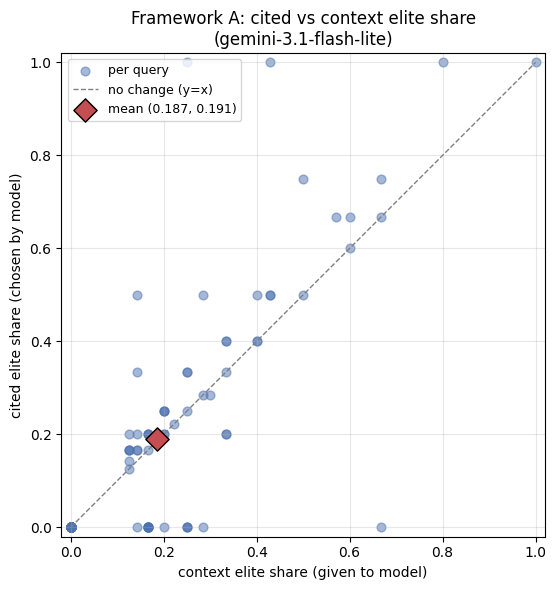

saved figure -> /kaggle/working/rq2_frameworkA_scatter.png
saved result -> /kaggle/working/rq2_frameworkA_result.json

result contents:
{
  "model": "gemini-3.1-flash-lite",
  "n_queries_used": 99,
  "n_excluded_empty_denom": 1,
  "mean_amplification": 0.004052429052429054,
  "median_amplification": 0.0,
  "ci_95_low": -0.025444925444925444,
  "ci_95_high": 0.03422468734968733,
  "ci_crosses_zero": true,
  "n_amplifying": 31,
  "n_reducing": 17,
  "n_unchanged": 51,
  "random_seed": 42,
  "n_bootstrap": 10000
}


In [21]:
# Cell 9: figure + save final result
import matplotlib.pyplot as plt
import numpy as np
import json

# 1) gather per-query points where BOTH shares are defined
xs, ys = [], []
for r in per_query:
    if r["context_elite_share"] is not None and r["cited_elite_share"] is not None:
        xs.append(r["context_elite_share"])
        ys.append(r["cited_elite_share"])
xs, ys = np.array(xs), np.array(ys)

# 2) scatter with diagonal reference line
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xs, ys, alpha=0.5, s=40, color="#4C72B0", label="per query")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="no change (y=x)")

# mean point
mean_x, mean_y = float(np.mean(xs)), float(np.mean(ys))
ax.scatter([mean_x], [mean_y], color="#C44E52", s=140, marker="D",
           edgecolor="black", zorder=5, label=f"mean ({mean_x:.3f}, {mean_y:.3f})")

ax.set_xlabel("context elite share (given to model)")
ax.set_ylabel("cited elite share (chosen by model)")
ax.set_title("Framework A: cited vs context elite share\n(gemini-3.1-flash-lite)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

FIG_PATH = "/kaggle/working/rq2_frameworkA_scatter.png"
plt.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("saved figure ->", FIG_PATH)

# 3) save the final result json (from Cell 8's frameworkA_result)
RESULT_PATH = "/kaggle/working/rq2_frameworkA_result.json"
with open(RESULT_PATH, "w") as f:
    json.dump(frameworkA_result, f, ensure_ascii=False, indent=2)
print("saved result ->", RESULT_PATH)
print("\nresult contents:")
print(json.dumps(frameworkA_result, ensure_ascii=False, indent=2))

## Cell 10 - Framework A conclusion

**Pre-registered question.** Does the generation stage amplify elite
institutional representation, i.e. does the model cite elite-institution papers
at a higher rate than they appear in the retrieved context it was given?

**Answer (measured, gemini-3.1-flash-lite).** No amplification is confirmed.
The mean amplification is +0.004 with a query-level bootstrap 95% CI of
[-0.025, +0.034], which crosses zero. The model's cited elite share (0.191)
essentially matches the context elite share (0.187) it was given.

**Which pre-registered outcome this is.** Of the two outcomes fixed in advance
(amplification present vs. neutral), this is the NEUTRAL outcome: no clear
elite citation amplification at the generation stage.

**Coherence across the study.** This mirrors RQ1 at the retrieval stage
(weak, not significant) and the PCA finding that the embedding encodes topic
rather than institution. Retrieval, generation, and representation all point
the same way: this pipeline shows no clear institutional bias.

**Honest limits.** Not significant means not confirmed, not proven zero. The
result is specific to the model actually used (gemini-3.1-flash-lite, after the
planned models were unavailable). It measures cited-source attribution under a
controlled RAG prompt, not token-level provenance. The 54.3% figure from other
sources is not comparable (different elite definition and pipeline).

**Framework A is complete.** Outputs: rq2_frameworkA_per_query.json,
rq2_frameworkA_result.json, rq2_frameworkA_scatter.png, plus the raw generation
checkpoint rq2_gen_checkpoint.jsonl.

In [22]:
import os
print(os.listdir("/kaggle/working"))

['rq2_frameworkA_scatter.png', '.virtual_documents', 'rq2_gen_checkpoint.jsonl', 'rq2_frameworkA_per_query.json', 'rq2_frameworkA_result.json']


In [23]:
from IPython.display import FileLink, display
import os
for p in [
    "/kaggle/working/rq2_frameworkA_result.json",
    "/kaggle/working/rq2_frameworkA_per_query.json",
    "/kaggle/working/rq2_frameworkA_scatter.png",
    "/kaggle/working/rq2_gen_checkpoint.jsonl",
]:
    print("OK" if os.path.exists(p) else "MISSING", p)
    if os.path.exists(p):
        display(FileLink(p))

OK /kaggle/working/rq2_frameworkA_result.json


/kaggle/working/rq2_frameworkA_result.json

OK /kaggle/working/rq2_frameworkA_per_query.json


/kaggle/working/rq2_frameworkA_per_query.json

OK /kaggle/working/rq2_frameworkA_scatter.png


/kaggle/working/rq2_frameworkA_scatter.png

OK /kaggle/working/rq2_gen_checkpoint.jsonl


/kaggle/working/rq2_gen_checkpoint.jsonl